In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 55.9 MB/s eta 0:00:00


In [2]:
import pennylane as qml
import pennylane.numpy as pnp
import pandas as pd
import numpy as np
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import time

SEED = 42
np.random.seed(SEED)

# ── Kept small for speed ───────────────────────────────────────────────────────
N_QUBITS    = 2
N_LAYERS    = 2
N_STEPS     = 30
BATCH_SIZE  = 15
LR          = 0.05
N_TRAIN     = 30
N_TEST_OK   = 15
N_TEST_ANOM = 10

print(f"Qubits: {N_QUBITS} | Layers: {N_LAYERS} | Steps: {N_STEPS} | Train: {N_TRAIN}")
print(f"Trainable params: {N_LAYERS * N_QUBITS * 2}")

Qubits: 2 | Layers: 2 | Steps: 30 | Train: 30
Trainable params: 8


In [3]:
dev = qml.device("default.qubit", wires=N_QUBITS)


def ansatz(x, params):
    """Simple 2-qubit ansatz: data encoding + trainable rotations + CNOT."""
    for layer in range(N_LAYERS):
        for q in range(N_QUBITS):
            qml.RX(x[q % len(x)], wires=q)
            qml.RY(params[layer, q, 0], wires=q)
            qml.RZ(params[layer, q, 1], wires=q)
        qml.CNOT(wires=[0, 1])


@qml.qnode(dev)
def kernel_circuit(x1, x2, params):
    ansatz(x1, params)
    qml.adjoint(ansatz)(x2, params)
    return qml.probs(wires=range(N_QUBITS))


def kernel_fn(x1, x2, params):
    # No float() cast — keeps autograd tape intact
    return kernel_circuit(x1, x2, params)[0]


print("Quantum kernel defined.")

Quantum kernel defined.


In [5]:
# ── Data loading ───────────────────────────────────────────────────────────────
datFile = pd.read_csv('sensor_data.csv')
X = datFile[['Temperature', 'Humidity']].values
y = np.where(datFile['Occupancy'] == 0, 1, -1)

scaler = MinMaxScaler(feature_range=(0, np.pi))
X = scaler.fit_transform(X)

nidx = np.where(y == 1)[0]
aidx = np.where(y == -1)[0]

rng = np.random.default_rng(SEED)
rng.shuffle(nidx)
rng.shuffle(aidx)

X_train = X[nidx[:N_TRAIN]]
y_train = y[nidx[:N_TRAIN]]  # ±1 labels for training
test_idx = np.concatenate([nidx[N_TRAIN:N_TRAIN + N_TEST_OK], aidx[:N_TEST_ANOM]])
X_test   = X[test_idx]
y_test   = y[test_idx]

perm   = rng.permutation(len(y_test))
X_test = X_test[perm]
y_test = y_test[perm]

print(f"Train: {len(X_train)} | Test normal: {(y_test==1).sum()} | Test anomaly: {(y_test==-1).sum()}")

Train: 30 | Test normal: 15 | Test anomaly: 10


In [6]:
# ── KTA training ───────────────────────────────────────────────────────────────
def kta_loss(params, X_batch, y_batch):
    K = qml.kernels.square_kernel_matrix(
        X_batch,
        lambda x1, x2: kernel_fn(x1, x2, params),
        assume_normalized_kernel=False
    )
    # Correct ideal kernel: T_ij = y_i * y_j  (labels must be ±1)
    # Same class → +1, different class → -1
    y = y_batch.reshape(-1, 1).astype(float)
    T = y @ y.T

    # Frobenius inner product <K, T>
    kta = pnp.sum(K * T) / (pnp.linalg.norm(K) * pnp.linalg.norm(T) + 1e-8)
    return -kta


params = pnp.array(
    np.random.uniform(0, 2 * np.pi, (N_LAYERS, N_QUBITS, 2)),
    requires_grad=True
)
opt = qml.AdamOptimizer(stepsize=LR)
kta_history = []

print(f"Training — {N_STEPS} steps ...")
t0 = time.time()

for step in range(N_STEPS):
    idx = np.random.choice(len(X_train), BATCH_SIZE, replace=False)
    X_batch = X_train[idx]
    y_batch = y_train[idx]  # ±1 labels for the batch

    def cost(p):
        return kta_loss(p, X_batch, y_batch)

    params, loss_val = opt.step_and_cost(cost, params)
    kta_history.append(-float(loss_val))

    if (step + 1) % 5 == 0:
        print(f"  Step {step+1:2d}/{N_STEPS}  KTA={kta_history[-1]:.4f}  [{time.time()-t0:.0f}s]")

print(f"\nDone in {time.time()-t0:.1f}s  |  Final KTA: {kta_history[-1]:.4f}")

Training — 30 steps ...
  Step  5/30  KTA=0.9629  [22s]
  Step 10/30  KTA=0.9670  [38s]
  Step 15/30  KTA=0.9842  [55s]
  Step 20/30  KTA=0.9922  [72s]
  Step 25/30  KTA=0.9987  [89s]
  Step 30/30  KTA=0.9872  [106s]

Done in 105.7s  |  Final KTA: 0.9872


In [7]:
# ── Build kernel matrices & classify ──────────────────────────────────────────
print("Building kernel matrices ...")
t0 = time.time()

K_train = qml.kernels.square_kernel_matrix(
    X_train, lambda x1, x2: kernel_fn(x1, x2, params),
    assume_normalized_kernel=True
)
K_test = qml.kernels.kernel_matrix(
    X_test, X_train, lambda x1, x2: kernel_fn(x1, x2, params)
)
print(f"Done in {time.time()-t0:.1f}s")

# Auto-scale
scale   = 1.0 / (K_train.mean() + 1e-8)
K_train_s = K_train * scale
K_test_s  = K_test  * scale

# Grid-search nu
best_acc, best_pred = 0, None
for nu in [0.05, 0.10, 0.15, 0.20]:
    preds = OneClassSVM(kernel="precomputed", nu=nu).fit(K_train_s).predict(K_test_s)
    acc   = accuracy_score(y_test, preds)
    print(f"  nu={nu}  acc={acc:.2%}")
    if acc > best_acc:
        best_acc, best_pred = acc, preds

y_pred = best_pred
print(f"\n✅ Best accuracy: {best_acc:.2%}")

Building kernel matrices ...
Done in 21.0s
  nu=0.05  acc=96.00%
  nu=0.1  acc=84.00%
  nu=0.15  acc=84.00%
  nu=0.2  acc=84.00%

✅ Best accuracy: 96.00%


              precision    recall  f1-score   support

Anomaly (-1)       1.00      0.90      0.95        10
 Normal (+1)       0.94      1.00      0.97        15

    accuracy                           0.96        25
   macro avg       0.97      0.95      0.96        25
weighted avg       0.96      0.96      0.96        25



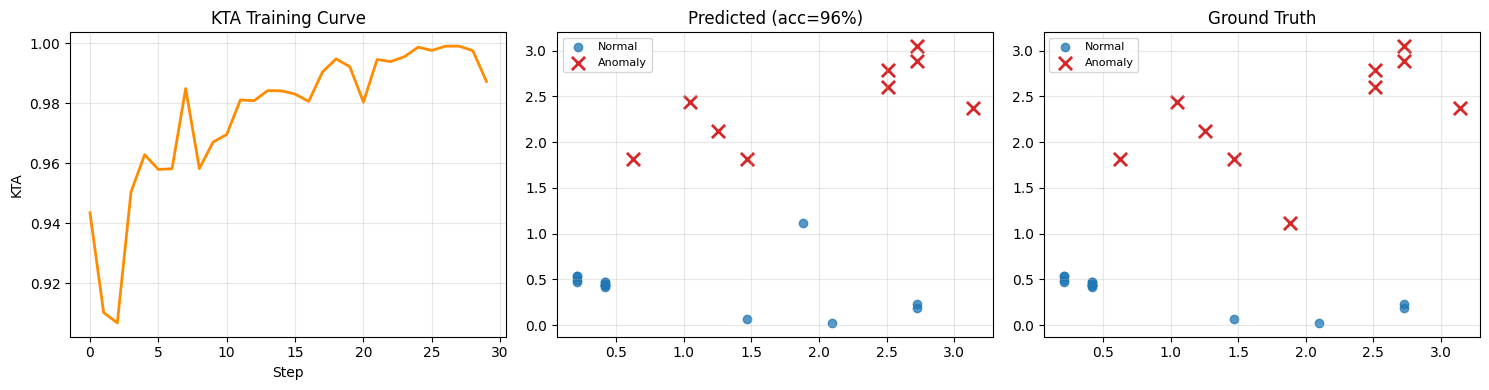

Saved anomaly_detection_fast.png


In [8]:
print(classification_report(y_test, y_pred,
      target_names=["Anomaly (-1)", "Normal (+1)"], zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(kta_history, lw=2, color='darkorange')
axes[0].set_title('KTA Training Curve'); axes[0].set_xlabel('Step')
axes[0].set_ylabel('KTA'); axes[0].grid(alpha=0.3)

for ax, labels, title in zip(
    axes[1:],
    [y_pred, y_test],
    [f'Predicted (acc={best_acc:.0%})', 'Ground Truth']
):
    ax.scatter(X_test[labels== 1,0], X_test[labels== 1,1],
               c='tab:blue', label='Normal', alpha=0.75)
    ax.scatter(X_test[labels==-1,0], X_test[labels==-1,1],
               c='tab:red', marker='x', s=90, lw=2, label='Anomaly')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('anomaly_detection_fast.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved anomaly_detection_fast.png')